# 1. Carga de datos
Lectura inicial y exploración general del dataset.

In [1]:
import pandas as pd

DATA_PATH = r"C:\Users\jhono\Downloads\Proyecto Mineria de Datos\mdi_detenidosaprehendidos_pm_2019_2024.xlsx"
df_original = pd.read_excel(DATA_PATH)

print("Dimensiones del dataset original:")
print(df_original.shape)

Dimensiones del dataset original:
(489847, 33)


In [2]:
print("Columnas del dataset:")
for col in df_original.columns:
    print(col)

Columnas del dataset:
codigo_iccs
tipo
estado_civil
estatus_migratorio
edad
sexo
genero
nacionalidad
autoidentificacion_etnica
nivel_de_instruccion
condicion
movilizacion
tipo_arma
arma
fecha_detencion_aprehension
hora_detencion_aprehension
lugar
tipo_lugar
nombre_zona
nombre_subzona
codigo_distrito
nombre_distrito
codigo_circuito
nombre_circuito
codigo_subcircuito
nombre_subcircuito
codigo_provincia
nombre_provincia
codigo_canton
nombre_canton
codigo_parroquia
nombre_parroquia
presunta_infraccion


In [3]:
df_original.head()

,codigo_iccs,tipo,estado_civil,estatus_migratorio,edad,sexo,genero,nacionalidad,autoidentificacion_etnica,nivel_de_instruccion,...,nombre_circuito,codigo_subcircuito,nombre_subcircuito,codigo_provincia,nombre_provincia,codigo_canton,nombre_canton,codigo_parroquia,nombre_parroquia,presunta_infraccion
0,SIN_DATO,DETENIDO,CASADO/A,SIN_DATO,50,HOMBRE,SIN_DATO,ECUATORIANO,MESTIZO/A,SECUNDARIO,...,YANTZAZA,19D04C01S01,YANTZAZA 1,19,ZAMORA CHINCHIPE,1905,YANTZAZA,190550-190551,"CHICANA, YANTZAZA (YANZATZA)",INFRACCIÓN
1,SIN_DATO,DETENIDO,SOLTERO/A,SIN_DATO,35,HOMBRE,SIN_DATO,ECUATORIANO,MESTIZO/A,SIN_DATO,...,NAMBIJA,19D01C06S02,NAMBIJA 2,19,ZAMORA CHINCHIPE,1901,ZAMORA,190151-190156-190158,"CUMBARATZA, SAN CARLOS DE LAS MINAS, TIMBARA",OTROS
2,SIN_DATO,DETENIDO,CASADO/A,SIN_DATO,51,HOMBRE,SIN_DATO,ECUATORIANO,MONTUBIO/A,SECUNDARIO,...,SAMBORONDÓN,09D23C01S04,SAMBORONDÓN 4,9,GUAYAS,916,SAMBORONDÓN,091650,SAMBORONDON,"DELITOS CONTRA LA ACTIVIDAD HIDROCARBURÍFERA, ..."
3,SIN_DATO,DETENIDO,SOLTERO/A,SIN_DATO,25,HOMBRE,SIN_DATO,ECUATORIANO,SIN_DATO,SECUNDARIO,...,ZUMBA,19D03C03S01,ZUMBA 1,19,ZAMORA CHINCHIPE,1902,CHINCHIPE,190250,ZUMBA,APREMIO
4,SIN_DATO,DETENIDO,SOLTERO/A,SIN_DATO,21,HOMBRE,SIN_DATO,ECUATORIANO,MESTIZO/A,SECUNDARIO,...,HUAMBI,14D03C01S01,HUAMBI 1,14,MORONA SANTIAGO,1406,SUCÚA,140652,HUAMBI,CONTRAVENCIONES


In [4]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489847 entries, 0 to 489846
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   codigo_iccs                  489847 non-null  object        
 1   tipo                         489847 non-null  object        
 2   estado_civil                 489847 non-null  object        
 3   estatus_migratorio           489847 non-null  object        
 4   edad                         489847 non-null  object        
 5   sexo                         489847 non-null  object        
 6   genero                       489847 non-null  object        
 7   nacionalidad                 489847 non-null  object        
 8   autoidentificacion_etnica    489847 non-null  object        
 9   nivel_de_instruccion         489847 non-null  object        
 10  condicion                    489847 non-null  object        
 11  movilizacion              

In [5]:
df_original['presunta_infraccion'].value_counts().head(30)

presunta_infraccion
DELITOS CONTRA EL DERECHO A LA PROPIEDAD                                                                               86007
BOLETAS                                                                                                                74107
DELITOS POR LA PRODUCCIÓN O TRÁFICO ILÍCITO DE SUSTANCIAS CATALOGADAS SUJETAS A FISCALIZACIÓN                          68484
CONTRAVENCIONES DE TRÁNSITO                                                                                            41550
CONTRAVENCIÓN DE VIOLENCIA CONTRA LA MUJER O MIEMBROS DEL NÚCLEO FAMILIAR                                              33334
DELITOS DE VIOLENCIA CONTRA LA MUJER O MIEMBROS DEL NÚCLEO FAMILIAR                                                    28746
DELITOS CONTRA LA SEGURIDAD PÚBLICA                                                                                    27869
CONTRAVENCIONES                                                                                          

In [6]:
df_original['tipo_arma'].value_counts().head(20)

tipo_arma
NINGUNA                                       358849
SIN_DATO                                       89335
ARMAS DE FUEGO                                 26382
ARMAS BLANCAS (OBJETO CORTANTE O PUNZANTE)     15281
Name: count, dtype: int64

In [7]:
df_original['hora_detencion_aprehension'].head(10)

0    02:15:00
1    06:10:00
2    07:30:00
3    04:00:00
4    07:45:00
5    03:00:00
6    09:30:00
7    10:30:00
8    12:00:00
9    05:00:00
Name: hora_detencion_aprehension, dtype: object

In [8]:
(df_original == "SIN_DATO").sum().sort_values(ascending=False).head(15)

codigo_iccs                    167906
estatus_migratorio              89335
genero                          89335
movilizacion                    89335
tipo_arma                       89335
arma                            89335
condicion                       40196
nivel_de_instruccion             8222
autoidentificacion_etnica        5529
edad                             5369
estado_civil                      207
nacionalidad                       73
nombre_parroquia                    8
presunta_infraccion                 1
fecha_detencion_aprehension         0
dtype: int64

# 2. Limpieza y ETL
Estandarización, tratamiento de nulos y creación de variables derivadas.

In [9]:
for col in df_original.select_dtypes(include="object").columns:
    df_original[col] = df_original[col].str.strip().str.upper()

In [10]:
pd.to_datetime(df_original["hora_detencion_aprehension"], errors="coerce").isna().sum()

C:\Users\jhono\AppData\Local\Temp\ipykernel_18888\3536537129.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_original["hora_detencion_aprehension"], errors="coerce").isna().sum()


np.int64(0)

In [11]:
df_original["edad"] = pd.to_numeric(df_original["edad"], errors="coerce")
df_original["edad"].describe()

count    484478.000000
mean         32.208740
std          10.995326
min          12.000000
25%          24.000000
50%          30.000000
75%          38.000000
max          98.000000
Name: edad, dtype: float64

In [12]:
df = df_original.copy()

In [13]:
cols_missing = [
    "tipo_arma",
    "arma",
    "estatus_migratorio",
    "movilizacion",
    "condicion",
    "nivel_de_instruccion",
    "autoidentificacion_etnica"
]

for col in cols_missing:
    if col in df.columns:
        df[col] = df[col].replace("SIN_DATO", pd.NA)

In [14]:
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")

df["edad"].describe()

count    484478.000000
mean         32.208740
std          10.995326
min          12.000000
25%          24.000000
50%          30.000000
75%          38.000000
max          98.000000
Name: edad, dtype: float64

In [15]:
df["fecha_detencion_aprehension"] = pd.to_datetime(
    df["fecha_detencion_aprehension"],
    errors="coerce"
)

df["anio"] = df["fecha_detencion_aprehension"].dt.year
df["mes"] = df["fecha_detencion_aprehension"].dt.month
df["dia_semana"] = df["fecha_detencion_aprehension"].dt.dayofweek

df[["anio","mes","dia_semana"]].head()

,anio,mes,dia_semana
0,2019,2,2
1,2019,1,5
2,2019,2,2
3,2019,1,3
4,2019,1,1


In [16]:
df["hora_detencion_aprehension"] = pd.to_datetime(
    df["hora_detencion_aprehension"],
    format="%H:%M:%S",
    errors="coerce"
)

df["hora"] = df["hora_detencion_aprehension"].dt.hour

df["hora"].describe()

count    489847.000000
mean         12.955617
std           6.422912
min           0.000000
25%           9.000000
50%          13.000000
75%          18.000000
max          23.000000
Name: hora, dtype: float64

In [17]:
df["fin_semana"] = df["dia_semana"].isin([5,6]).astype(int)

df["es_noche"] = ((df["hora"] >= 18) | (df["hora"] < 6)).astype(int)

df[["hora","es_noche","fin_semana"]].head()

,hora,es_noche,fin_semana
0,2,1,0
1,6,0,1
2,7,0,0
3,4,1,0
4,7,0,0


# 3. Construcción de variable objetivo
Definición de la etiqueta `alta_gravedad` a partir de reglas de negocio.

In [18]:
alta_lista = [
    "DELITOS CONTRA LA INVIOLABILIDAD DE LA VIDA",
    "DELITOS CONTRA LA INTEGRIDAD SEXUAL Y REPRODUCTIVA",
    "DELITOS CONTRA LA INTEGRIDAD PERSONAL",
    "TERRORISMO Y SU FINANCIACIÓN"
]

df["alta_gravedad"] = df["presunta_infraccion"].isin(alta_lista).astype(int)

# Si usó arma de fuego → alta gravedad
df.loc[df["tipo_arma"] == "ARMAS DE FUEGO", "alta_gravedad"] = 1

df["alta_gravedad"].value_counts(normalize=True)

alta_gravedad
0    0.883805
1    0.116195
Name: proportion, dtype: float64

In [19]:
df["alta_gravedad"].value_counts(normalize=True)

alta_gravedad
0    0.883805
1    0.116195
Name: proportion, dtype: float64

In [20]:
df["anio"].value_counts().sort_index()

anio
2019    89335
2020    82994
2021    90622
2022    79608
2023    73863
2024    73425
Name: count, dtype: int64

# 4. Codificación
Definición de features y configuración del preprocesamiento numérico/categórico.

In [21]:
features = [
    "edad",
    "es_noche",
    "fin_semana",
    "sexo",
    "nombre_provincia",
    "tipo_lugar",
    "tipo_arma"
]

print("Features definidas:")
print(features)

Features definidas:
['edad', 'es_noche', 'fin_semana', 'sexo', 'nombre_provincia', 'tipo_lugar', 'tipo_arma']


In [22]:
num_features = ["edad", "es_noche", "fin_semana"]

cat_features = ["sexo", "nombre_provincia", "tipo_lugar", "tipo_arma"]

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

# Modelo
model = LogisticRegression(max_iter=1000)

# Pipeline completo
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", model)
])

In [24]:
from sklearn.impute import SimpleImputer

# Para numéricas
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Para categóricas
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="DESCONOCIDO")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

# 5. División temporal
Separación de entrenamiento y prueba por año para evitar fuga temporal.

In [25]:
df_train = df[df["anio"] < 2024].copy()
df_test = df[df["anio"] == 2024].copy()

print("Train:", df_train.shape)
print("Test:", df_test.shape)

Train: (416422, 40)
Test: (73425, 40)


In [26]:
X_train = df_train[features]
y_train = df_train["alta_gravedad"]

X_test = df_test[features]
y_test = df_test["alta_gravedad"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (416422, 7)
X_test: (73425, 7)


In [27]:
import numpy as np

X_train = X_train.replace({pd.NA: np.nan})
X_test = X_test.replace({pd.NA: np.nan})

# 6. Modelos
Entrenamiento y evaluación de modelos base y avanzados.

In [28]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
from sklearn.metrics import roc_auc_score

y_pred_proba = pipeline.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_pred_proba)

print("AUC:", auc)

AUC: 0.8283710236899197


In [30]:
from sklearn.metrics import confusion_matrix

y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cm

array([[62756,     1],
       [ 4788,  5880]])

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      1.00      0.96     62757
           1       1.00      0.55      0.71     10668

    accuracy                           0.93     73425
   macro avg       0.96      0.78      0.84     73425
weighted avg       0.94      0.93      0.93     73425



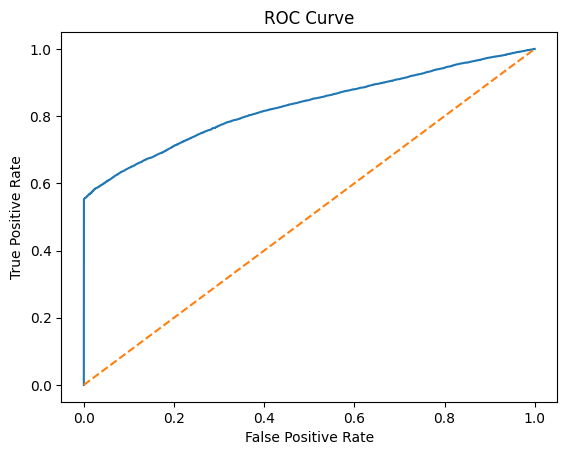

In [32]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [48]:
## Logística sin arma
features_sin_arma = [
    "edad",
    "es_noche",
    "fin_semana",
    "sexo",
    "nombre_provincia",
    "tipo_lugar"
]

num_features2 = ["edad", "es_noche", "fin_semana"]
cat_features2 = ["sexo", "nombre_provincia", "tipo_lugar"]

num_transformer2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="DESCONOCIDO")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor2 = ColumnTransformer(
    transformers=[
        ("num", num_transformer2, num_features2),
        ("cat", cat_transformer2, cat_features2)
    ]
)

pipeline2 = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("classifier", LogisticRegression(max_iter=1000))
])

X_train2 = df_train[features_sin_arma]
X_test2 = df_test[features_sin_arma]
X_train2 = X_train2.replace({pd.NA: np.nan})
X_test2 = X_test2.replace({pd.NA: np.nan})

pipeline2.fit(X_train2, y_train)

y_pred_proba2 = pipeline2.predict_proba(X_test2)[:,1]
auc2 = roc_auc_score(y_test, y_pred_proba2)

print("AUC Logística sin arma:", auc2)


AUC Logística sin arma: 0.6547188131133688


In [49]:
## Logística mínima (solo features temporales)
features_min = [
    "edad",
    "es_noche",
    "fin_semana"
]

num_features3 = ["edad", "es_noche", "fin_semana"]
cat_features3 = []

num_transformer3 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor3 = ColumnTransformer(
    transformers=[
        ("num", num_transformer3, num_features3)
    ]
)

pipeline3 = Pipeline(steps=[
    ("preprocessor", preprocessor3),
    ("classifier", LogisticRegression(max_iter=1000))
])

X_train3 = df_train[features_min]
X_test3 = df_test[features_min]
X_train3 = X_train3.replace({pd.NA: np.nan})
X_test3 = X_test3.replace({pd.NA: np.nan})

pipeline3.fit(X_train3, y_train)

y_pred_proba3 = pipeline3.predict_proba(X_test3)[:,1]
auc3 = roc_auc_score(y_test, y_pred_proba3)

print("AUC Logística mínima:", auc3)


AUC Logística mínima: 0.5567973163269023


In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

In [35]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
from sklearn.metrics import roc_auc_score

y_pred_proba_rf = rf_pipeline.predict_proba(X_test)[:,1]

auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("AUC RandomForest:", auc_rf)

AUC RandomForest: 0.8084617268639498


In [37]:
import pandas as pd

# Obtener nombres de variables transformadas
feature_names_rf = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Importancias
importances = rf_pipeline.named_steps["classifier"].feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": feature_names_rf,
    "importance": importances
}).sort_values(by="importance", ascending=False)

rf_importance_df.head(15)

,feature,importance
142,cat__tipo_arma_ARMAS DE FUEGO,0.460027
0,num__edad,0.217842
144,cat__tipo_arma_NINGUNA,0.122223
143,cat__tipo_arma_DESCONOCIDO,0.061137
141,cat__tipo_arma_ARMAS BLANCAS (OBJETO CORTANTE ...,0.029434
1,num__es_noche,0.011966
2,num__fin_semana,0.010025
15,cat__nombre_provincia_GUAYAS,0.006935
139,cat__tipo_lugar_ÁREAS DE ACCESO PÚBLICO,0.005003
138,cat__tipo_lugar_ÁREA PRIVADA,0.004600


In [38]:
from sklearn.ensemble import GradientBoostingClassifier

In [39]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

In [40]:
gb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
y_pred_proba_gb = gb_pipeline.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score

auc_gb = roc_auc_score(y_test, y_pred_proba_gb)

print("AUC GradientBoosting:", auc_gb)

AUC GradientBoosting: 0.8411397687041593


In [42]:
import xgboost as xgb

In [43]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

In [44]:
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
y_pred_proba_xgb = xgb_pipeline.predict_proba(X_test)[:,1]

auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("AUC XGBoost:", auc_xgb)

AUC XGBoost: 0.8442386429312378


# 7. Comparación
Resumen tabular del desempeño de los modelos entrenados.

In [50]:
resultados = pd.DataFrame({
    "Modelo": [
        "Logística mínima",
        "Logística sin arma",
        "Logística completa",
        "RandomForest",
        "GradientBoosting",
        "XGBoost"
    ],
    "AUC": [
        auc3,
        auc2,
        auc,
        auc_rf,
        auc_gb,
        auc_xgb
    ]
})

resultados.sort_values(by="AUC", ascending=False)

,Modelo,AUC
5,XGBoost,0.844239
4,GradientBoosting,0.841140
2,Logística completa,0.828371
3,RandomForest,0.808462
1,Logística sin arma,0.654719
0,Logística mínima,0.556797


# 8. Gráficos
Curvas ROC y visualizaciones para interpretar resultados.

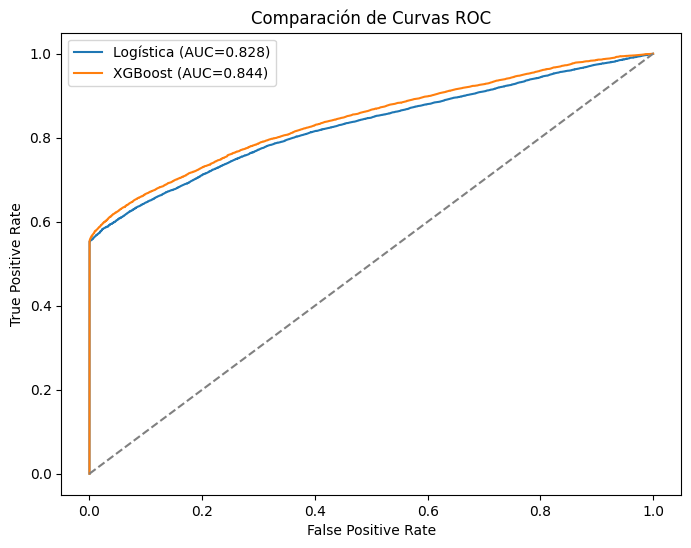

In [51]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Logística
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr_log, tpr_log, label=f"Logística (AUC={auc:.3f})")

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})")

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparación de Curvas ROC")
plt.legend()
plt.show()

In [52]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_xgb = xgb_pipeline.predict(X_test)

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[62743    14]
 [ 4754  5914]]
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     62757
           1       1.00      0.55      0.71     10668

    accuracy                           0.94     73425
   macro avg       0.96      0.78      0.84     73425
weighted avg       0.94      0.94      0.93     73425



In [53]:
feature_names_xgb = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances_xgb = xgb_pipeline.named_steps["classifier"].feature_importances_

xgb_importance_df = pd.DataFrame({
    "feature": feature_names_xgb,
    "importance": importances_xgb
}).sort_values(by="importance", ascending=False)

xgb_importance_df.head(15)

,feature,importance
142,cat__tipo_arma_ARMAS DE FUEGO,0.773032
143,cat__tipo_arma_DESCONOCIDO,0.042832
136,cat__tipo_lugar_VÍA PÚBLICA,0.017829
141,cat__tipo_arma_ARMAS BLANCAS (OBJETO CORTANTE ...,0.014170
139,cat__tipo_lugar_ÁREAS DE ACCESO PÚBLICO,0.012448
144,cat__tipo_arma_NINGUNA,0.011461
87,cat__tipo_lugar_INSTITUCIONES DE SALUD,0.007999
51,cat__tipo_lugar_CENTRO DE REHABILITACIÓN SOCIA...,0.007703
138,cat__tipo_lugar_ÁREA PRIVADA,0.006317
140,cat__tipo_lugar_ÁREAS DEDICADAS AL COMERCIO,0.005113


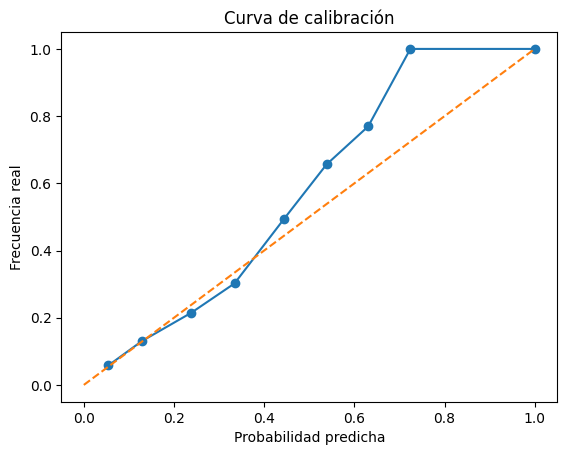

In [54]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_pred_proba_xgb, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia real")
plt.title("Curva de calibración")
plt.show()

In [55]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("AUC CV:", cv_scores.mean())

AUC CV: 0.8148699527735737


In [56]:
ejemplo = pd.DataFrame({
    "edad": [60],
    "es_noche": [1],
    "fin_semana": [0],
    "sexo": ["HOMBRE"],
    "nombre_provincia": ["GUAYAS"],
    "tipo_lugar": ["VÍA PÚBLICA"],
    "tipo_arma": ["ARMAS DE FUEGO"]
})

prob = xgb_pipeline.predict_proba(ejemplo)[0][1]

print("Probabilidad estimada de alta gravedad:", prob)

Probabilidad estimada de alta gravedad: 0.99976414


In [57]:
ejemplo_intermedio = pd.DataFrame({
    "edad": [28],
    "es_noche": [1],
    "fin_semana": [1],
    "sexo": ["HOMBRE"],
    "nombre_provincia": ["GUAYAS"],
    "tipo_lugar": ["VÍA PÚBLICA"],
    "tipo_arma": ["NINGUNA"]
})

prob_intermedio = xgb_pipeline.predict_proba(ejemplo_intermedio)[0][1]

print("Probabilidad intermedia estimada:", prob_intermedio)

Probabilidad intermedia estimada: 0.031478934


In [58]:
ejemplo_mixto = pd.DataFrame({
    "edad": [5],
    "es_noche": [0],                 # No es noche
    "fin_semana": [1],               # Sí es fin de semana
    "sexo": ["HOMBRE"],
    "nombre_provincia": ["COTOPAXI"],   # Provincia menos dominante
    "tipo_lugar": ["VIVIENDA/ALOJAMIENTO"],  # Lugar relativamente más seguro
    "tipo_arma": ["ARMAS DE FUEGO"]   # Factor fuerte
})

prob_mixto = xgb_pipeline.predict_proba(ejemplo_mixto)[0][1]

print("Probabilidad estimada (escenario mixto):", prob_mixto)


Probabilidad estimada (escenario mixto): 0.9997937


In [59]:
ejemplo_bajo = pd.DataFrame({
    "edad": [26],
    "es_noche": [0],
    "fin_semana": [0],
    "sexo": ["MUJER"],
    "nombre_provincia": ["COTOPAXI"],
    "tipo_lugar": ["VIVIENDA/ALOJAMIENTO"],
    "tipo_arma": ["NINGUNA"]
})

prob_bajo = xgb_pipeline.predict_proba(ejemplo_bajo)[0][1]

print("Probabilidad baja estimada:", prob_bajo)

Probabilidad baja estimada: 0.05416531


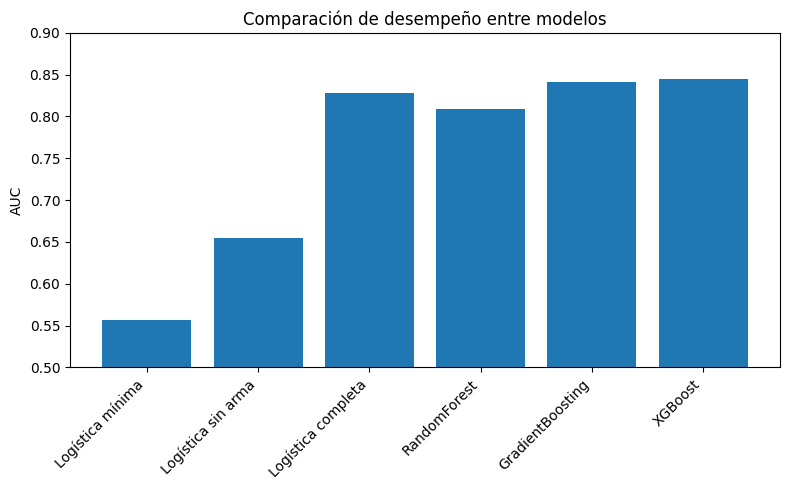

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(resultados["Modelo"], resultados["AUC"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("AUC")
plt.title("Comparación de desempeño entre modelos")
plt.ylim(0.5, 0.9)
plt.tight_layout()
plt.show()

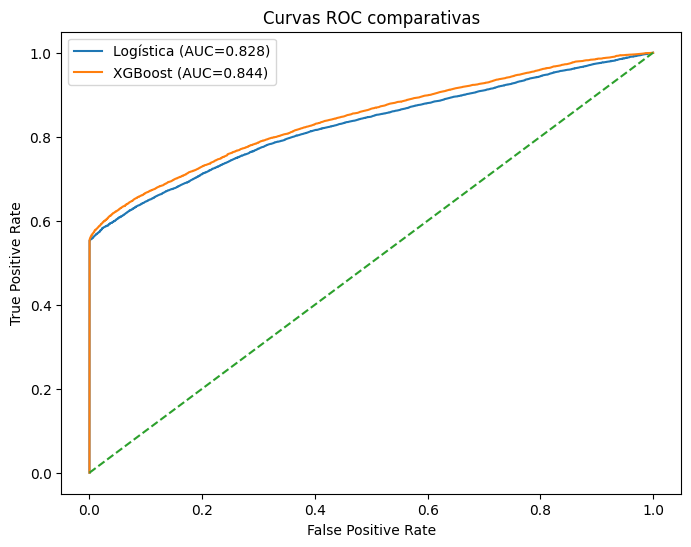

In [61]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr_log, tpr_log, label=f"Logística (AUC={auc:.3f})")

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC comparativas")
plt.legend()
plt.show()

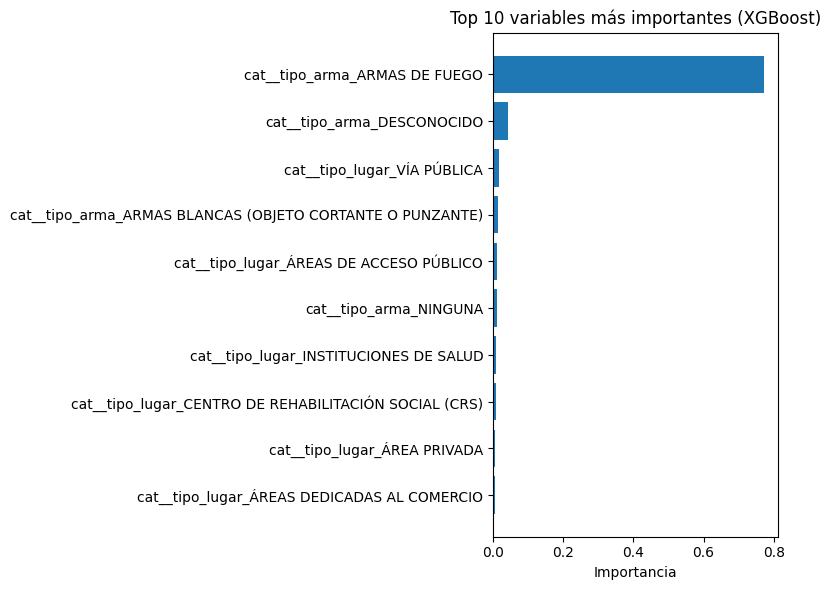

In [62]:
top10 = xgb_importance_df.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10["feature"], top10["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 variables más importantes (XGBoost)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

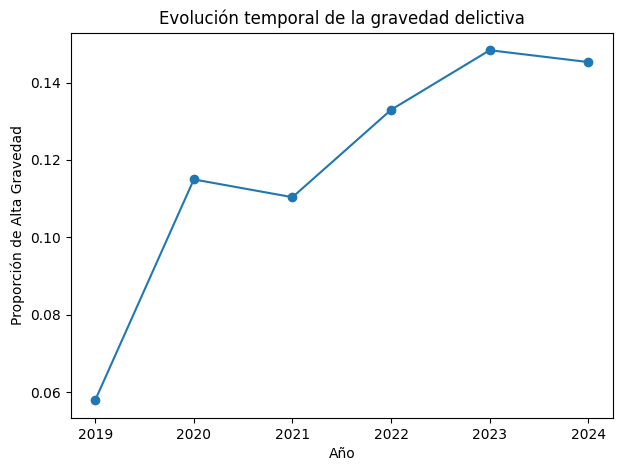

In [63]:
gravedad_anual = df.groupby("anio")["alta_gravedad"].mean()

plt.figure(figsize=(7,5))
plt.plot(gravedad_anual.index, gravedad_anual.values, marker="o")
plt.xlabel("Año")
plt.ylabel("Proporción de Alta Gravedad")
plt.title("Evolución temporal de la gravedad delictiva")
plt.show()

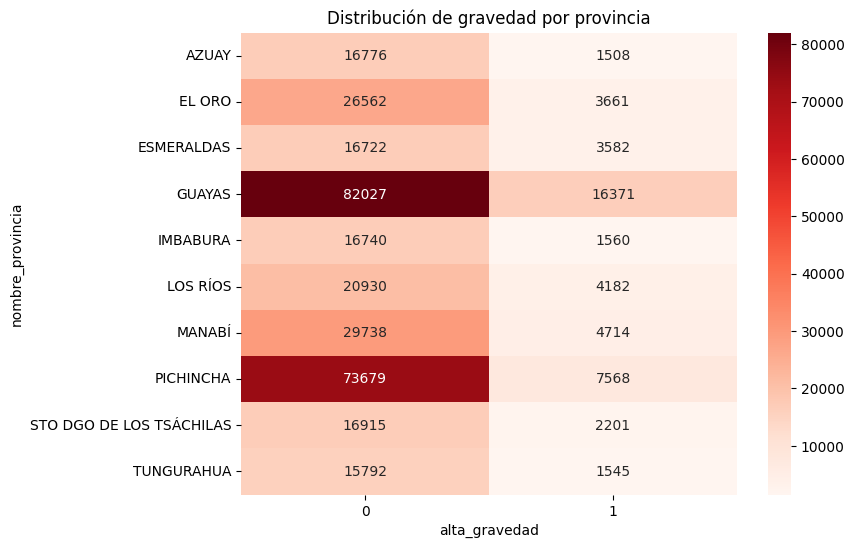

In [64]:
import seaborn as sns

top_provincias = df["nombre_provincia"].value_counts().head(10).index

heat_data = df[df["nombre_provincia"].isin(top_provincias)]
heat_data = heat_data.groupby(["nombre_provincia", "alta_gravedad"]).size().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(heat_data, annot=True, fmt="d", cmap="Reds")
plt.title("Distribución de gravedad por provincia")
plt.show()

In [65]:
ejemplo_mixto_sin_arma = pd.DataFrame({
    "edad": [35],
    "es_noche": [0],
    "fin_semana": [1],
    "sexo": ["HOMBRE"],
    "nombre_provincia": ["COTOPAXI"],
    "tipo_lugar": ["VIVIENDA/ALOJAMIENTO"]
})

prob_mixto_sin_arma = pipeline2.predict_proba(ejemplo_mixto_sin_arma)[0][1]

print("Probabilidad estimada (modelo sin arma):", prob_mixto_sin_arma)

Probabilidad estimada (modelo sin arma): 0.059594426564512186


In [66]:
ejemplo_alto_contexto = pd.DataFrame({
    "edad": [40],
    "es_noche": [1],
    "fin_semana": [1],
    "sexo": ["HOMBRE"],
    "nombre_provincia": ["GUAYAS"],
    "tipo_lugar": ["VÍA PÚBLICA"]
})

prob_alto_contexto = pipeline2.predict_proba(ejemplo_alto_contexto)[0][1]

print("Probabilidad estimada (alto contexto, sin arma):", prob_alto_contexto)

Probabilidad estimada (alto contexto, sin arma): 0.02704003466714725
